Read Files

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [8]:
clinical_data = pd.read_csv("datasets/clinical_data.csv")
lab_data1 = pd.read_csv("datasets/lab_data.csv")

For lab data, We need to use the most recent pre-operative measurement, consistent with clinical practice

In [9]:
preop = lab_data1[lab_data1['dt'] < 0]

preop_last = (preop.sort_values('dt').groupby(['caseid', 'name']).last()   
              .reset_index()[['caseid','dt', 'name', 'result']])

preop_last.head(10)

,caseid,dt,name,result
0,1,-38769,cl,100.00
1,1,-38769,k,3.50
2,1,-38769,na,141.00
3,2,-102589,cl,115.00
4,2,-101973,hb,10.20
5,2,-101973,hct,32.50
6,2,-102589,k,4.70
7,2,-102589,na,143.00
8,2,-101973,plt,251.00
9,2,-101973,wbc,4.36


In [10]:
#preop_last.to_excel("preop_lab_values.xlsx", index=False)

Change the row x column using piviot table in sheet 2

In [11]:
lab_data = pd.read_excel(r"datasets/preop_lab_values.xlsx", sheet_name = "Sheet2", header=1)

In [12]:
lab_data = lab_data.iloc[:-1, :-1]
lab_data.iloc[0:10]

,Unnamed: 0,alb,alt,ammo,aptt,ast,be,bun,ccr,cl,...,plt,po2,pt%,ptinr,ptsec,sao2,tbil,tprot,wbc,(blank)
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.0,...,251.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.36,NaN
2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,4.6,30.0,NaN,36.5,64.0,NaN,27.0,NaN,108.0,...,158.0,NaN,81.0,1.14,13.0,NaN,0.9,8.2,14.64,NaN
4,6,3.9,17.0,NaN,29.1,19.0,NaN,14.0,NaN,104.0,...,145.0,NaN,104.0,0.97,11.1,NaN,1.0,6.7,3.20,NaN
5,7,4.4,16.0,NaN,26.4,20.0,NaN,18.0,NaN,106.0,...,229.0,NaN,109.0,0.95,10.8,NaN,0.4,7.4,4.28,NaN
6,9,4.4,8.0,NaN,NaN,13.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.8,7.2,NaN,NaN
7,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,11,3.4,13.0,NaN,30.3,17.0,NaN,17.0,NaN,110.0,...,261.0,NaN,121.0,0.90,10.2,NaN,0.3,5.8,6.31,NaN
9,12,3.1,15.0,NaN,NaN,25.0,NaN,6.0,NaN,NaN,...,67.0,NaN,NaN,NaN,NaN,NaN,0.9,5.8,1.11,NaN


remove the coumns that has less than 75% of missing data

In [13]:
missing_rate = lab_data.isna().mean()
lab_data = lab_data.loc[:, missing_rate < 0.75]
lab_data = lab_data.rename(columns={"Unnamed: 0": "caseid"})
lab_data


,caseid,alb,alt,aptt,ast,bun,cl,cr,crp,fib,...,k,na,p,plt,pt%,ptinr,ptsec,tbil,tprot,wbc
0,1,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,...,3.5,141.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN,NaN,115.0,NaN,NaN,NaN,...,4.7,143.0,NaN,251.0,NaN,NaN,NaN,NaN,NaN,4.36
2,4,NaN,NaN,NaN,NaN,NaN,108.0,NaN,NaN,NaN,...,4.3,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,4.6,30.0,36.5,64.0,27.0,108.0,1.83,NaN,178.0,...,4.9,139.0,5.4,158.0,81.0,1.14,13.0,0.9,8.2,14.64
4,6,3.9,17.0,29.1,19.0,14.0,104.0,1.07,0.01,183.0,...,3.4,141.0,2.8,145.0,104.0,0.97,11.1,1.0,6.7,3.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5434,6385,3.7,28.0,NaN,18.0,19.0,109.0,0.84,NaN,NaN,...,4.0,144.0,NaN,239.0,NaN,NaN,NaN,0.6,5.9,5.45
5435,6386,NaN,NaN,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,4.5,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5436,6387,4.4,10.0,32.2,16.0,7.0,103.0,0.65,0.03,239.0,...,3.6,142.0,3.0,214.0,90.0,1.07,12.2,0.3,6.9,7.70
5437,6388,NaN,NaN,NaN,NaN,NaN,103.0,NaN,NaN,NaN,...,4.0,138.0,NaN,427.0,NaN,NaN,NaN,NaN,NaN,6.27


Box_plots

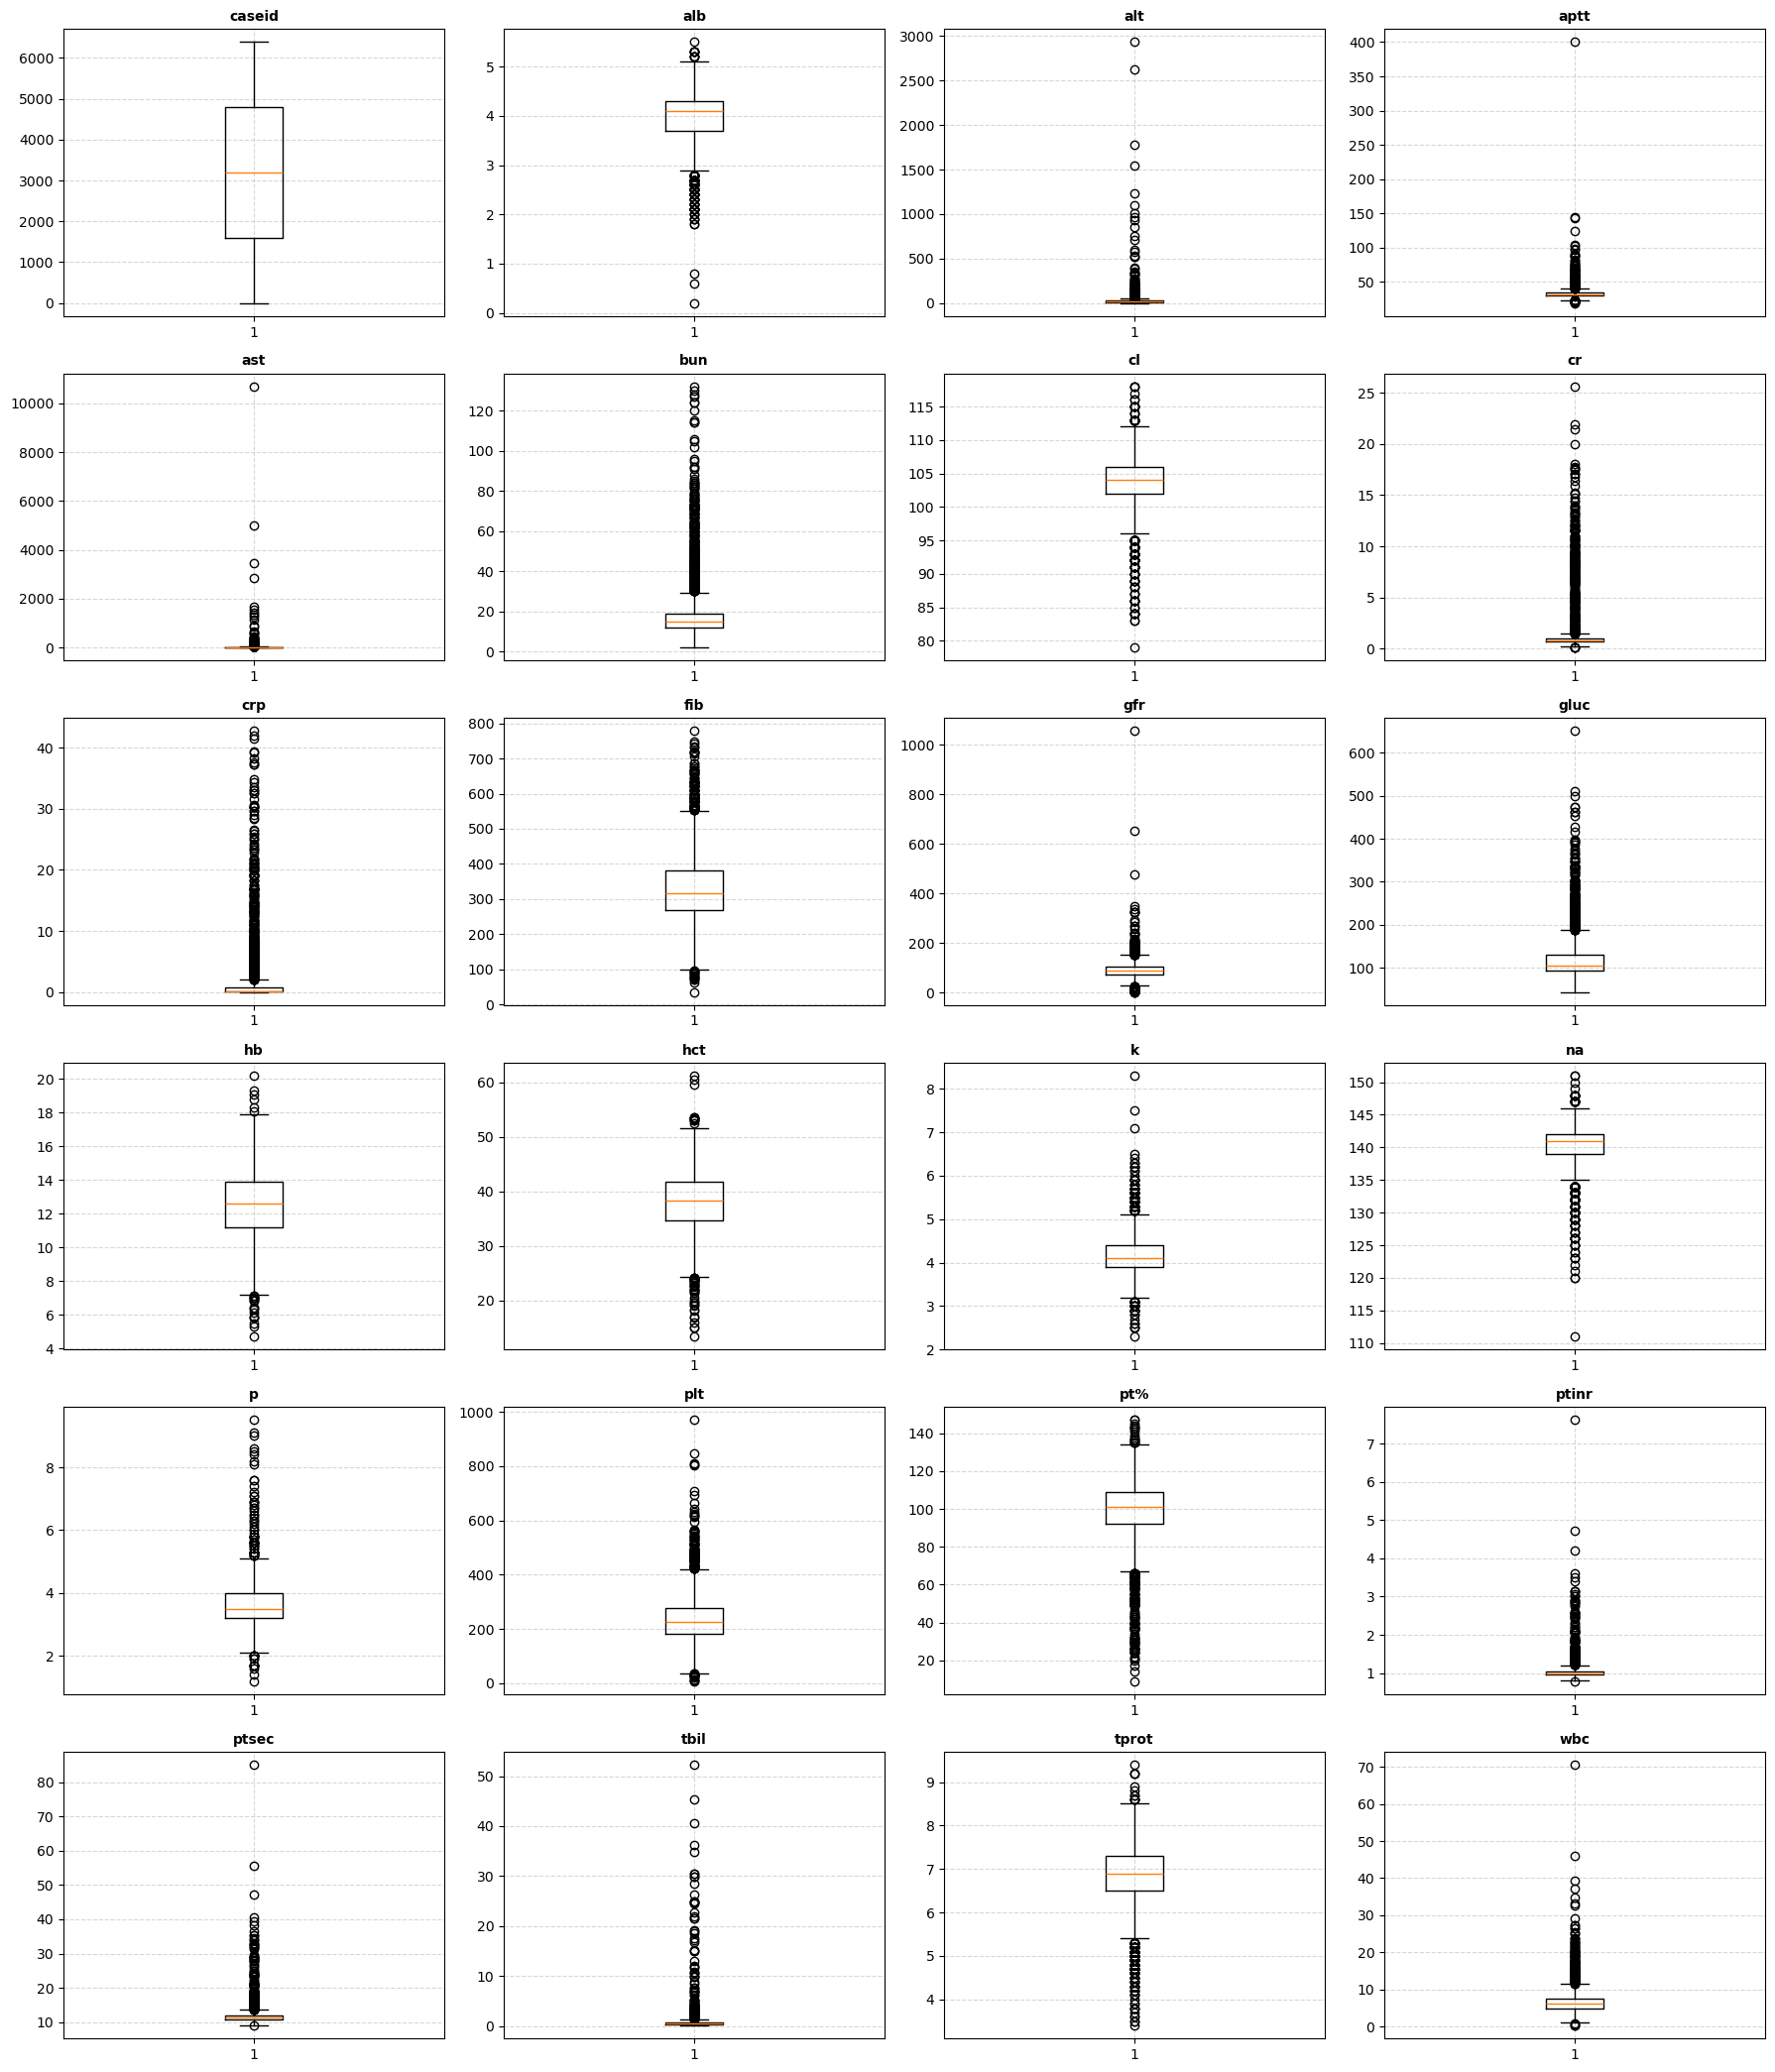

In [14]:
import math
import matplotlib.pyplot as plt
import pandas as pd


columns_to_check = []
for col in lab_data.columns:
    if "Unnamed" not in str(col):
        clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()
        if not clean_data.empty:
            columns_to_check.append(col)

#Calculate total rows needed for 6 per row
num_plots = len(columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))


for i, col in enumerate(columns_to_check, start=1):
    clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()

    plt.subplot(num_rows, 4, i)  # (rows, columns, plot number)
    plt.boxplot(clean_data)
    plt.title(col, fontsize=10, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Histogram of lab values

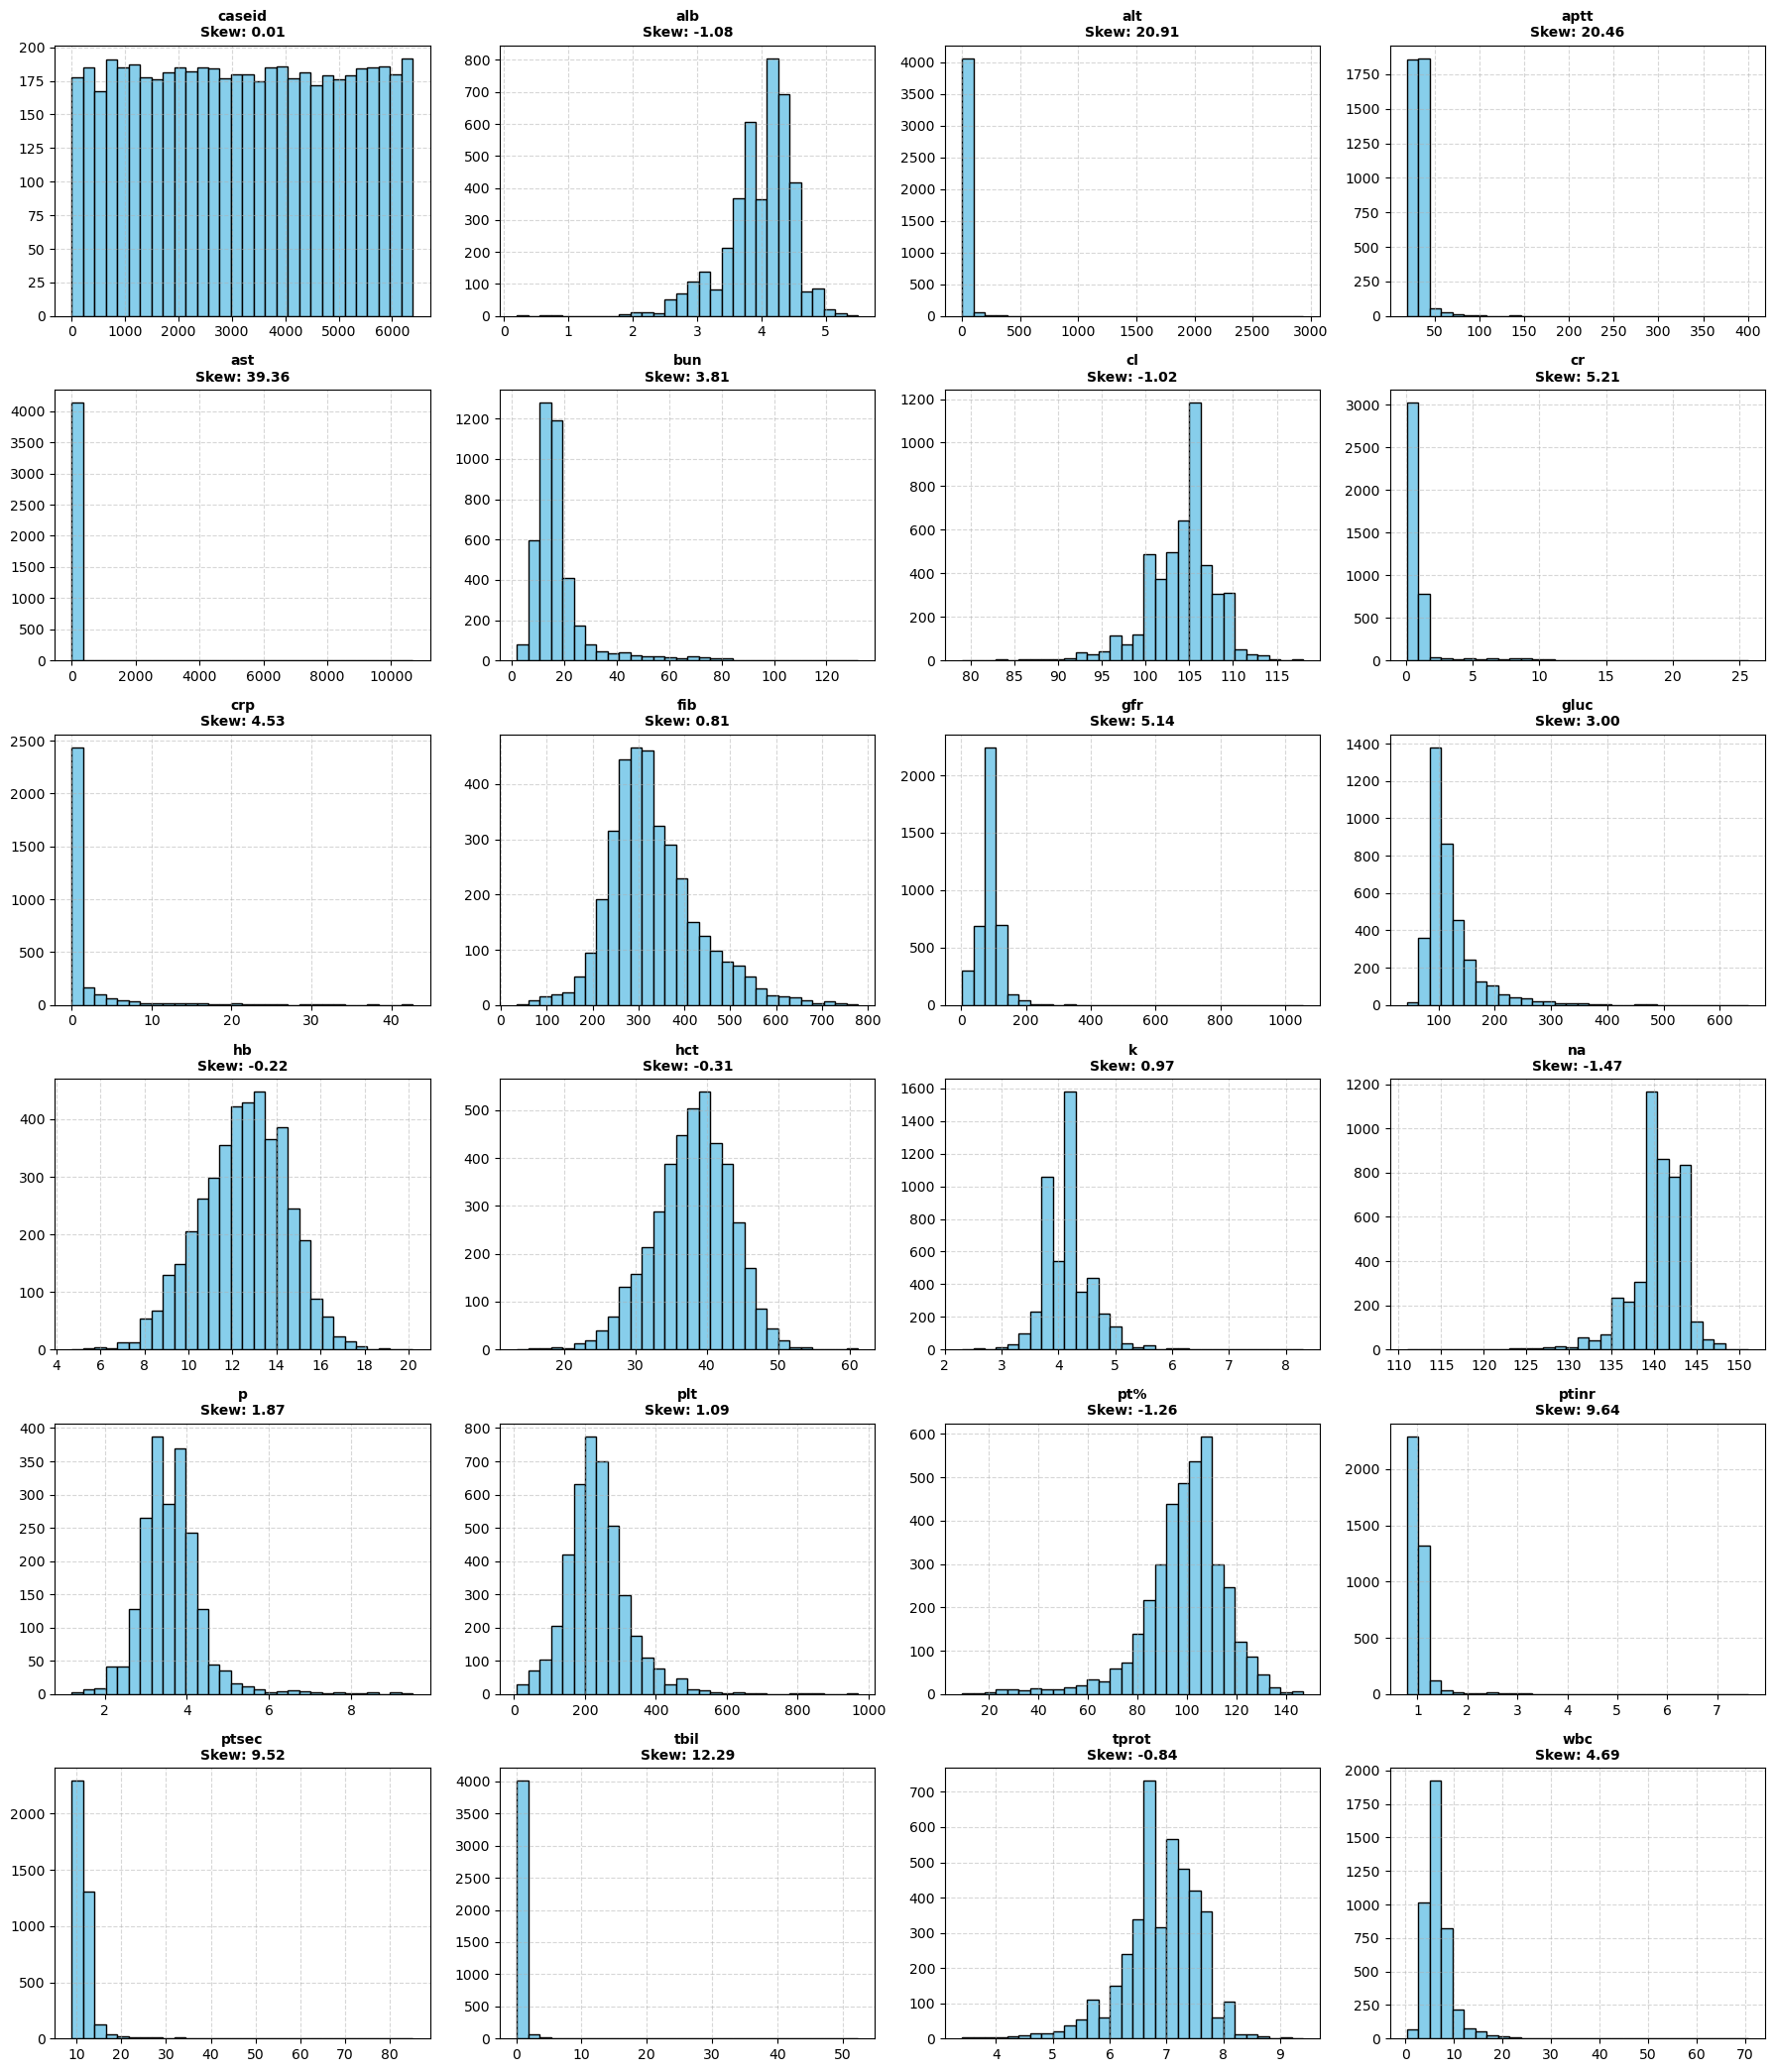

In [15]:

columns_to_check = []
for col in lab_data.columns:
    if "Unnamed" not in str(col):
        clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()
        if not clean_data.empty:
            columns_to_check.append(col)

#Calculate total rows needed for 6 per row
num_plots = len(columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))

for i, col in enumerate(columns_to_check, start=1):
    clean_data = pd.to_numeric(lab_data[col], errors="coerce").dropna()

    col_skew = clean_data.skew()

    plt.subplot(num_rows, 4, i)
    plt.hist(clean_data, bins=30, color="skyblue", edgecolor="black")
    plt.title(f"{col}\nSkew: {col_skew:.2f}", fontsize=10, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

histogram of numerical clinical values

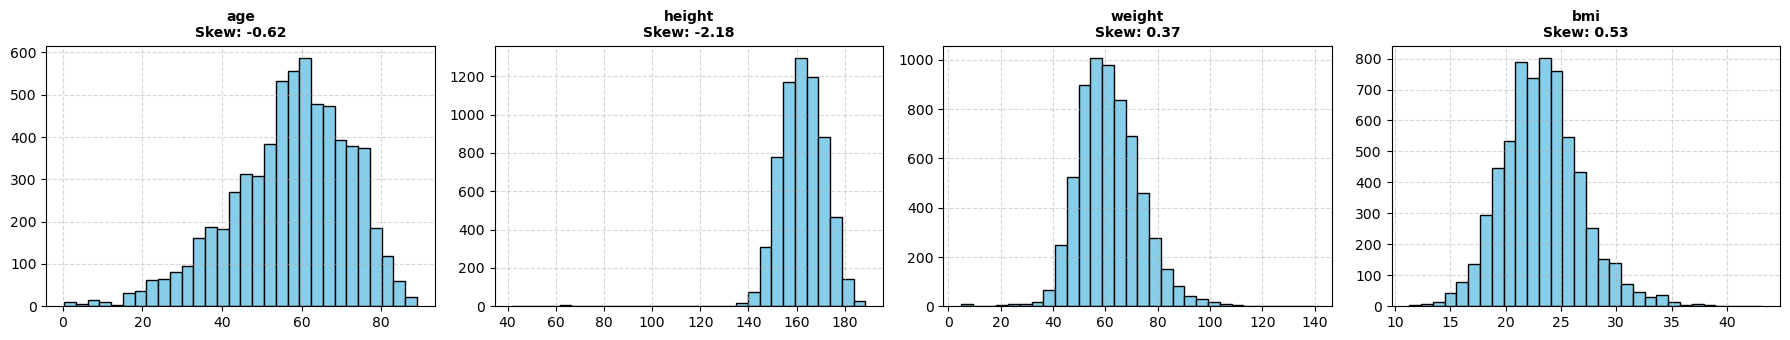

In [16]:
clinical_columns_to_check = ["age", "height", "weight", "bmi"]

num_plots = len(clinical_columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))

for i, col in enumerate(clinical_columns_to_check, start=1):
    clean_data = pd.to_numeric(clinical_data[col], errors="coerce").dropna()

    col_skew = clean_data.skew()

    plt.subplot(num_rows, 4, i)
    plt.hist(clean_data, bins=30, color="skyblue", edgecolor="black")
    plt.title(f"{col}\nSkew: {col_skew:.2f}", fontsize=10, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

clean clinical value

In [17]:
clinical_data = clinical_data[clinical_data["age"] != ">89"]

coleration of with clinical numerical vlaues

In [18]:
merged = clinical_data.merge(lab_data, on="caseid", how="inner")
print(merged.shape)  
clinical_vars = ["age","height", "weight", "bmi"]
lab_vars = ["hb", "hct", "fib", "k", "alb", "gfr","p","pt%","tprot"]

corr_matrix = merged[clinical_vars + lab_vars].corr(method="spearman")
cross_corr = corr_matrix.loc[clinical_vars, lab_vars]
print(cross_corr)

(5432, 97)
              hb       hct       fib         k       alb       gfr         p  \
age    -0.087965 -0.094167  0.201449  0.038081 -0.214760 -0.269827 -0.159537   
height  0.281233  0.266011 -0.060576  0.081401  0.081317  0.031451 -0.111085   
weight  0.385777  0.367016 -0.050454  0.023135  0.176678 -0.052340 -0.065363   
bmi     0.283271  0.269916 -0.016604 -0.035657  0.163909 -0.085272 -0.002626   

             pt%     tprot  
age     0.052486 -0.123760  
height -0.117304  0.051203  
weight  0.065363  0.149157  
bmi     0.158190  0.152222  


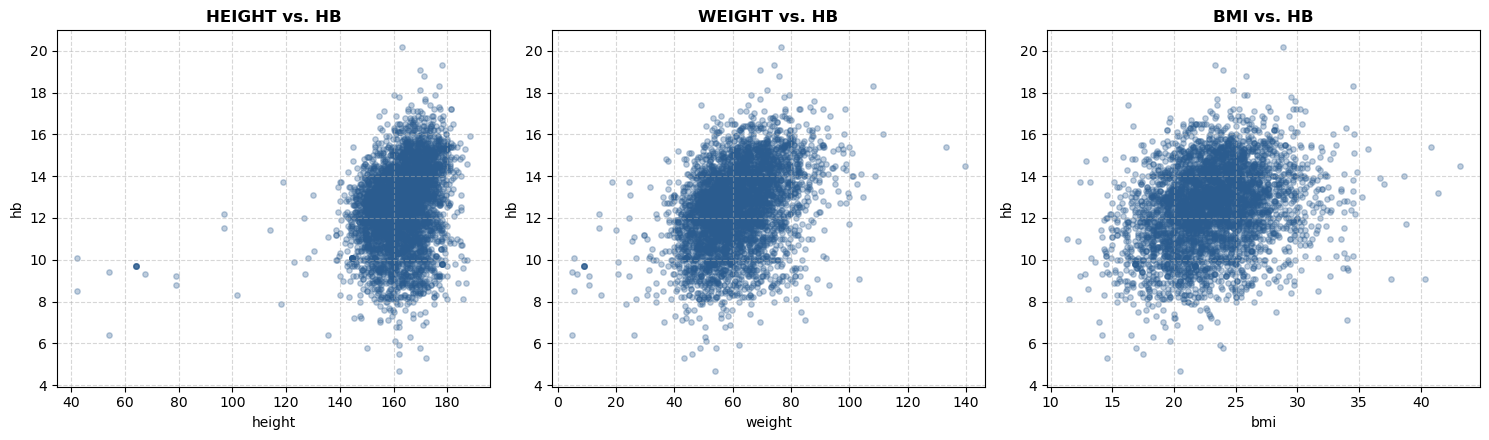

In [19]:
# List of clinical variables for the x-axis
x_vars = ["height", "weight", "bmi"]
y_var = "hb"

# Create a 1-row, 3-column figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, x_col in enumerate(x_vars):
    # Drop rows where either x or y is NaN for a clean plot
    valid_data = merged[[x_col, y_var]].dropna()

    axes[i].scatter(
        valid_data[x_col], valid_data[y_var], alpha=0.3, color="#2b5c8f", s=15
    )
    axes[i].set_title(f"{x_col.upper()} vs. {y_var.upper()}", fontweight="bold")
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_var)
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

histogram of with clinical categorical vlaues

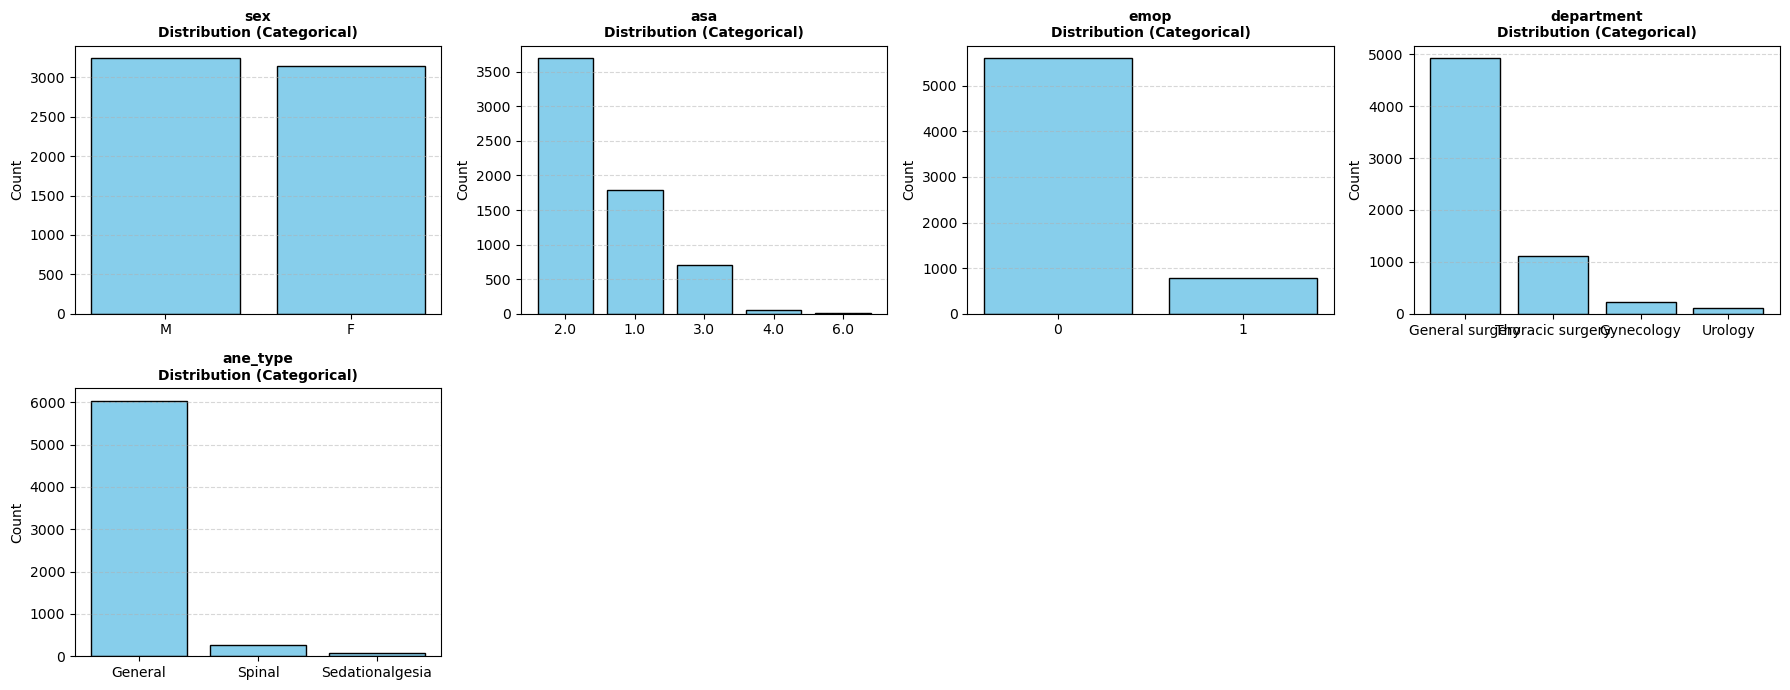

In [20]:
clinical_columns_to_check = ["sex","asa","emop","department","ane_type"]

num_plots = len(clinical_columns_to_check)
num_rows = math.ceil(num_plots / 4)

plt.figure(figsize=(18, 3.5 * num_rows))

for i, col in enumerate(clinical_columns_to_check, start=1):
    # Drop missing values and count occurrences of 'M' and 'F'
    counts = clinical_data[col].dropna().value_counts()

    plt.subplot(num_rows, 4, i)
    plt.bar(
        counts.index.astype(str), counts.values, color="skyblue", edgecolor="black"
    )
    plt.title(f"{col}\nDistribution (Categorical)", fontsize=10, fontweight="bold")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Correlation Ratio ($\eta$, Eta)

Association (Correlation Ratio eta: 0 = none, 1 = perfect):
               hb    hct
sex         0.272  0.244
asa         0.315  0.321
emop        0.184  0.207
department  0.171  0.163
ane_type    0.135  0.125


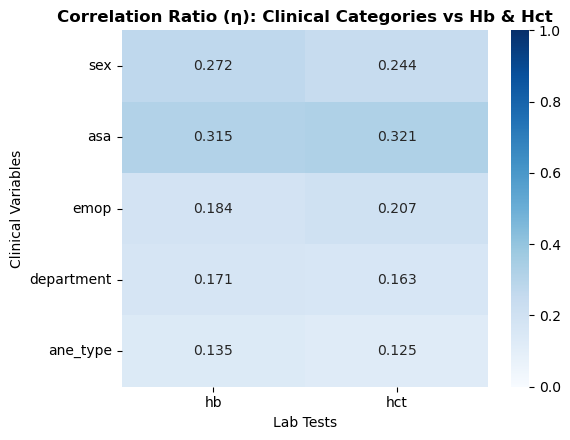

In [ ]:
def correlation_ratio(categories, values):
    """Calculates Eta (association between categorical and continuous)."""
    valid = ~(categories.isna() | values.isna())
    cats = categories[valid].to_numpy()
    vals = values[valid].to_numpy()

    if len(vals) == 0:
        return np.nan

    y_mean = np.mean(vals)
    ss_total = np.sum((vals - y_mean) ** 2)
    if ss_total == 0:
        return 0.0

    ss_between = 0.0
    for cat in np.unique(cats):
        sub = vals[cats == cat]
        ss_between += len(sub) * (np.mean(sub) - y_mean) ** 2

    return np.sqrt(ss_between / ss_total)


# merge two datasets with "caseid"
merged = clinical_data.merge(lab_data, on="caseid", how="inner")

clinical_vars = ["sex", "asa", "emop", "department", "ane_type"]
target_labs = ["hb", "hct"]


for col in target_labs:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

#Eta matrix
eta_matrix = pd.DataFrame(index=clinical_vars, columns=target_labs, dtype=float)

for clin in clinical_vars:
    for lab in target_labs:
        eta_matrix.loc[clin, lab] = correlation_ratio(merged[clin], merged[lab])


print("Association (Correlation Ratio eta: 0 = none, 1 = perfect):")
print(eta_matrix.round(3))


plt.figure(figsize=(6, 4.5))
sns.heatmap(
    eta_matrix, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, cbar=True
)
plt.title("Correlation Ratio (η): Clinical Categories vs Hb & Hct", fontweight="bold")
plt.ylabel("Clinical Variables")
plt.xlabel("Lab Tests")
plt.tight_layout()
plt.show()